# QNP-based SQD implementation for MOF

This notebook presents a simple Qiskit implementation of the QNP ansatz <br>
https://iopscience.iop.org/article/10.1088/1367-2630/ac2cb3/meta <br>
The specific case considered here is the (10,10) active space of the MOF-74. The simulation involves 20 qubits and 3 layers depth. This is not sufficient to achieve chemical accuracy within the standard VQE approach but, as shown below, noisy sample-based quantum diagonalization (SQD) can overcome these limitations.<br> 
To simplify future simulations on harware, the QNP ansatz uses fixed parameters obtained from Quicksilver (the optimization itself could be challenging in the presence of noise). 

Set up quantum circuit

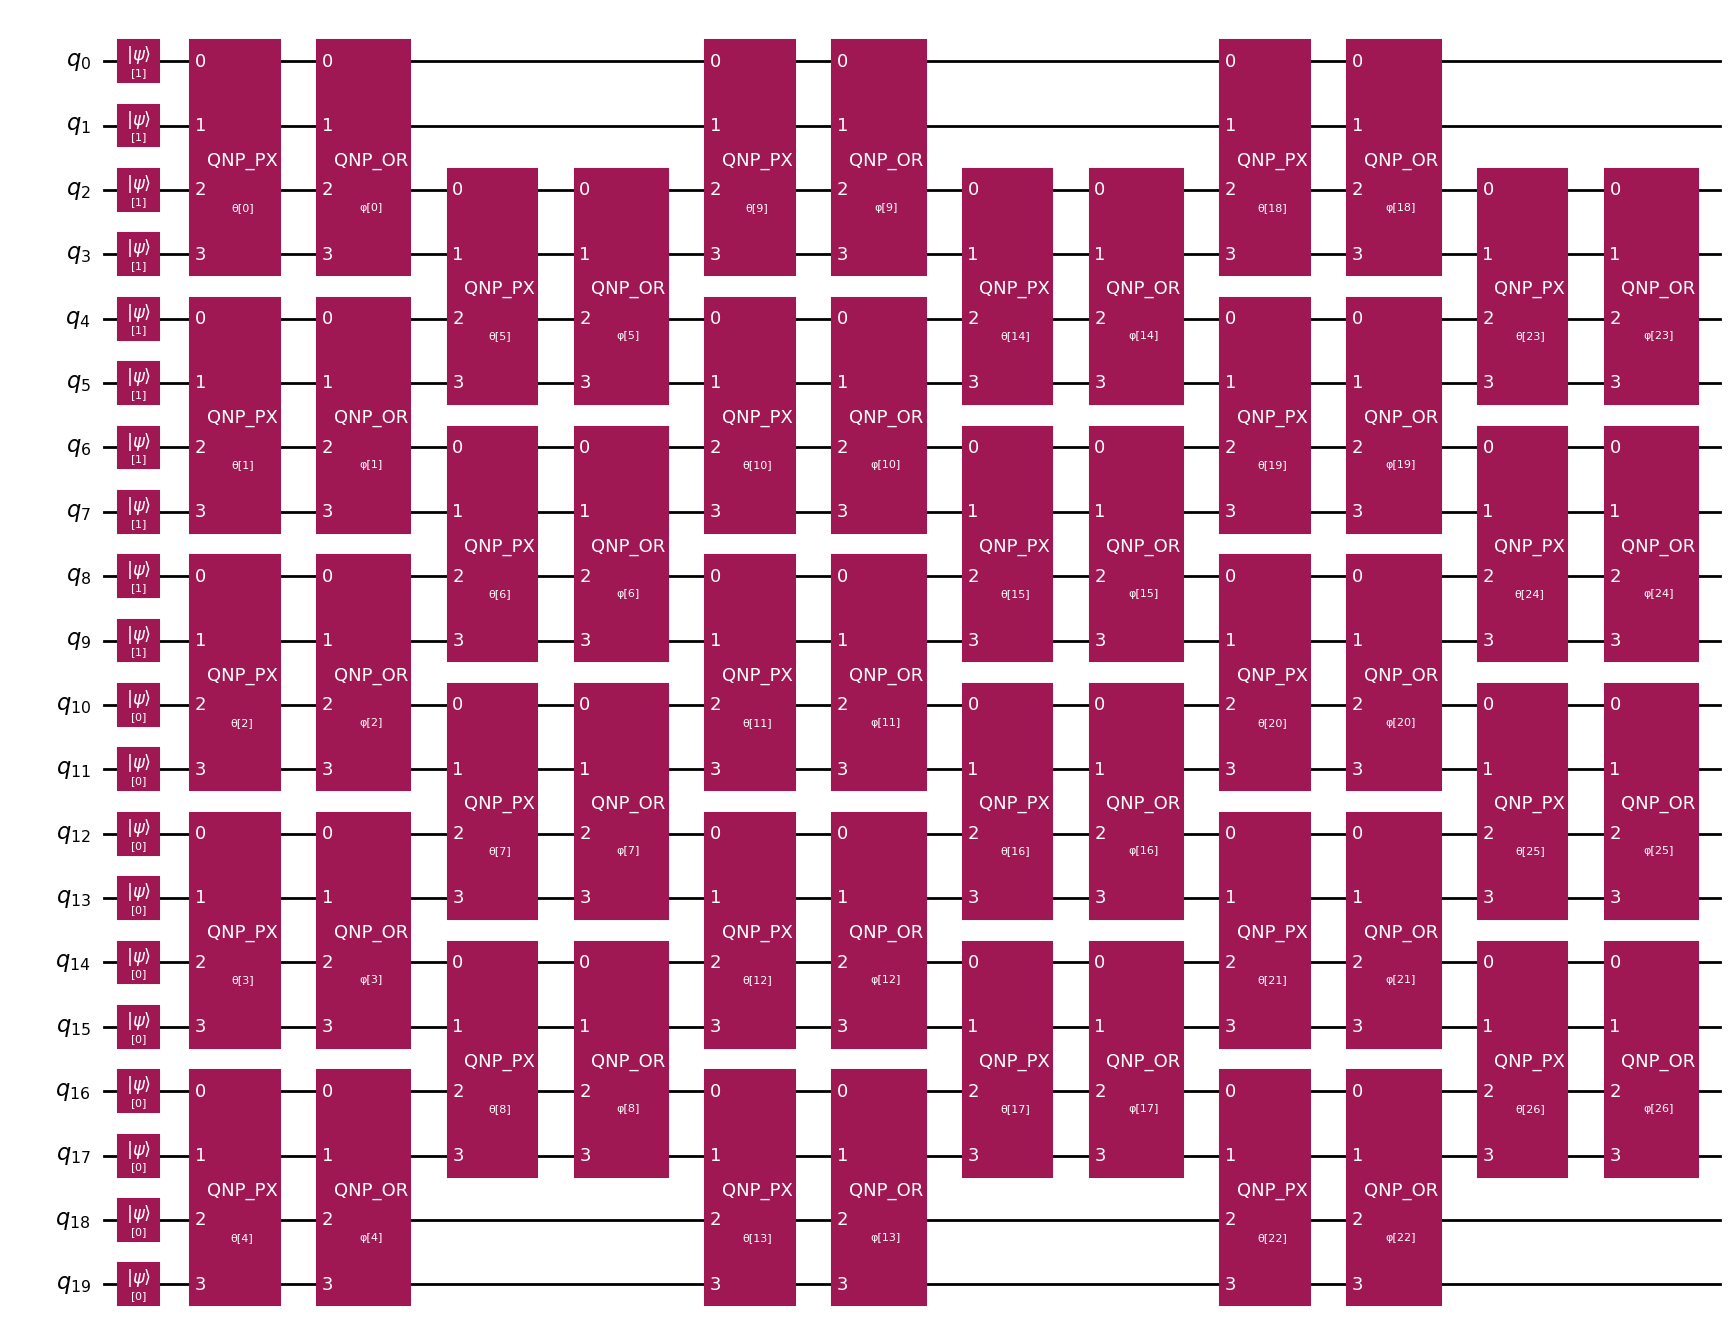

In [1]:
import numpy as np
import sys
sys.path.append('../../../qnp_vqe_qiskit_simulator/qnp_utils')
from qnp_utils import count_QNP_params, initialize_HF, QNP_fabric
from qiskit.circuit import ParameterVector
from qiskit import QuantumCircuit

n_layers = 3
n_qbits = 20
intfile = '../../../fullci_reference_pyscf/singlet/MOFintegrals.npz'
integrals = np.load(intfile)
nelec = int(integrals['Nelec'])

n_theta, n_phi = count_QNP_params(n_qbits, n_layers)

theta = ParameterVector('θ', n_theta)
phi = ParameterVector('φ', n_phi)

qnp_circ = QuantumCircuit(n_qbits)
initialize_HF(qnp_circ,nelec)
QNP_fabric(qnp_circ, n_layers, theta, phi)

# Draw the main circuit
qnp_circ.draw('mpl')

Set up Hamiltonian 

In [2]:
from qiskit_nature.second_q.hamiltonians import ElectronicEnergy
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit.quantum_info import SparsePauliOp
from qnp_utils import reorder_alphabeta_to_interleaved

#Load the active space integrals defining the Hamiltonian 
H0 = integrals['Ecore']
H1 = integrals['Hact']
H2 = integrals['Iact']

print(f"H0: {H0}")
print(f"H1 type: {type(H1)}, H1 shape {H1.shape}")
print(f"H2 type: {type(H2)}, H2 shape {H2.shape}")

#Setting up the electronic Hamiltonian from H1 and H2 integrals
hamiltonian = ElectronicEnergy.from_raw_integrals(H1, H2)
hamiltonian.nuclear_repulsion_energy = H0 # This is just a constant in the Hamiltonian

#Hamiltonian in second quantization
second_q_H = hamiltonian.second_q_op()

#Fermion to qubit mapping
mapper = JordanWignerMapper()
qubit_jw_H = mapper.map(second_q_H)

#Changing Pauli strings to interleaved order 
pauli_terms = qubit_jw_H.paulis  
coeffs = qubit_jw_H.coeffs
interleaved_pauli = reorder_alphabeta_to_interleaved(pauli_terms)
qubit_jw_H = SparsePauliOp.from_list(list(zip(interleaved_pauli, coeffs)))

H0: 0.0
H1 type: <class 'numpy.ndarray'>, H1 shape (10, 10)
H2 type: <class 'numpy.ndarray'>, H2 shape (10, 10, 10, 10)


Use Qiskit to compute the exact expectation value

Qiskit estimate of ground state energy (exact estimator): -55.08349325238582 Ha
Deviation from reference FCI: 0.19102860953063328 Ha
Deviation of Quicksilver:     0.19102860911692687 Ha


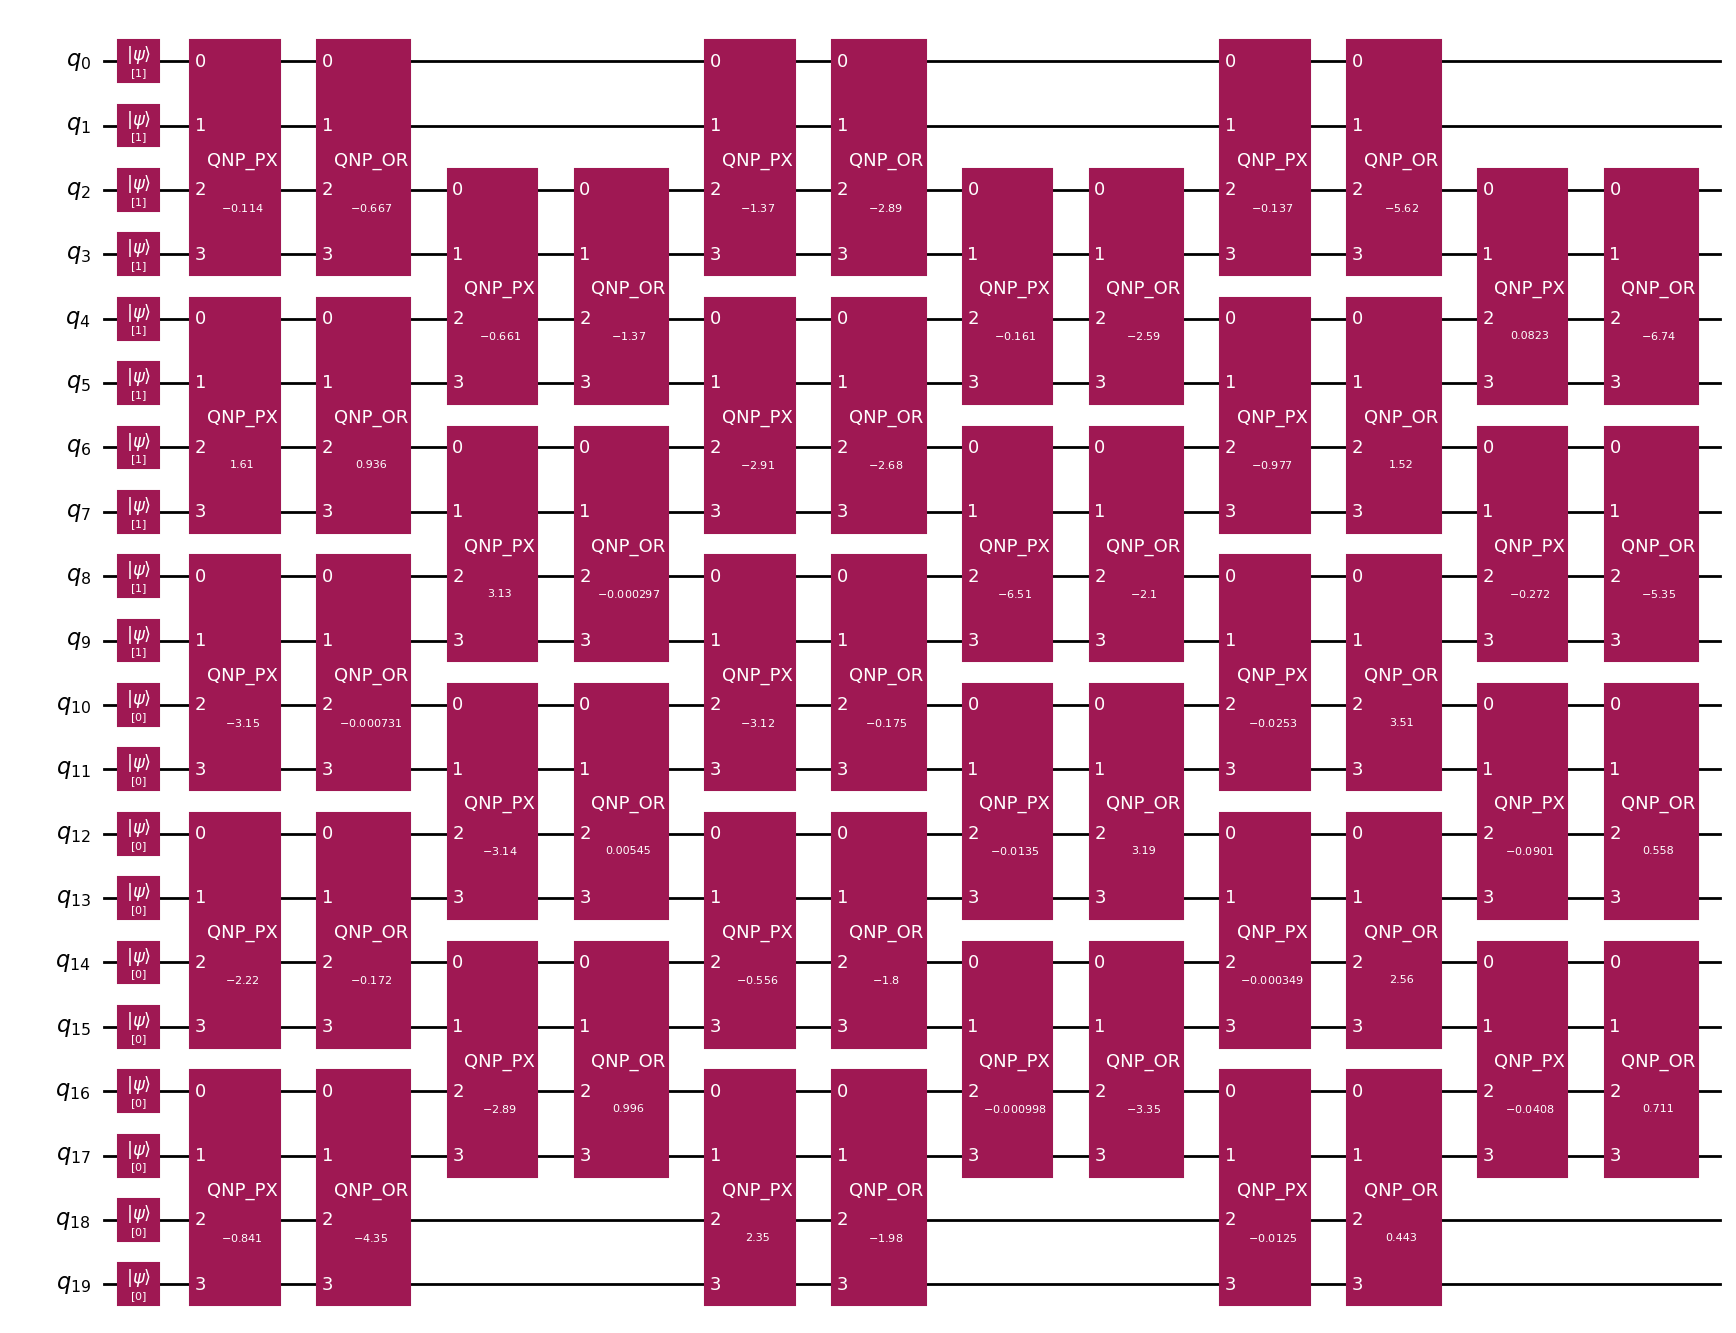

In [3]:
from qiskit.primitives import StatevectorEstimator
from qiskit.circuit import Parameter, ParameterVector
from qnp_utils import assign_parameters_from_file

#Reference FCI value
E_FCI = integrals['Efci']

exact_estimator = StatevectorEstimator()

parfile='optimized_params.txt'
qnp_fix_param = assign_parameters_from_file(parfile, qnp_circ, n_layers, theta, phi)

results = exact_estimator.run([(qnp_fix_param, qubit_jw_H)]).result()
qiskit_exact_GSenergy=results[0].data.evs+H0

print(f"Qiskit estimate of ground state energy (exact estimator): {qiskit_exact_GSenergy} Ha")
print(f"Deviation from reference FCI: {qiskit_exact_GSenergy-E_FCI} Ha")
print("Deviation of Quicksilver:     0.19102860911692687 Ha")
qnp_fix_param.draw('mpl')

### Sampling determinants from QNP using the exact simulator

In [6]:
from qiskit_aer import AerSimulator
from qiskit import transpile

#All qubits are measured to obtain the bitstrings
qnp_fix_param.measure_all()

simulator = AerSimulator(method='statevector')
circ_tm = transpile(qnp_fix_param, simulator)

#Using a relatively large number of shots to compare with the exact FCI wavefunction
nshots = 50000

#Since the bitstring generation takes a while it is better
#to run it once and save data to file
#result = simulator.run(circ_tm, shots=nshots).result()
#counts = result.get_counts(circ_tm)
#np.save("simulator_counts_fullcircuit.npy", counts, allow_pickle=True)
counts = np.load("simulator_counts_fullcircuit.npy", allow_pickle=True).item()

The results in the dictionary below were obtained with Pyscf and are useful for comparison. The keys contain the determinants and the values correspond to the squared coefficients in the wavefunction, sorted in decreasing order (only the 11 largest contributions are previded). 

In [7]:
pyscf_counts={'00011100001100101111': 0.07660734757443831, '00101100001100011111': 0.07660365812561762, '00101100000110011111': 0.05872813469411152, '00011100001001101111': 0.058721665057563543, '00011100001010011111': 0.028875384152233965, '00101100000101101111': 0.02887044083164174, '00101100001101001111': 0.01992301925435158, '00011100001110001111': 0.019912150034327867, '00011100001011001111': 0.018483618855150756, '00101100000111001111': 0.018483206070267478, '00111100000010011111': 0.014951907144312012}

If the QNP ansatz sampling misses some of the dominant determinants in the FCI wavefunction, most likely SQD will not be accurate.

In [8]:
for det, prob in pyscf_counts.items():

    if det in counts:
        qnp_prob = counts[det]/nshots
        print(f"Probability of {det}: {prob:.5f} in FCI and {qnp_prob:.5f} from QNP sampling")
    else:
        print(f"{det} has not been sampled by QNP")

Probability of 00011100001100101111: 0.07661 in FCI and 0.01612 from QNP sampling
Probability of 00101100001100011111: 0.07660 in FCI and 0.01672 from QNP sampling
Probability of 00101100000110011111: 0.05873 in FCI and 0.06334 from QNP sampling
Probability of 00011100001001101111: 0.05872 in FCI and 0.06262 from QNP sampling
Probability of 00011100001010011111: 0.02888 in FCI and 0.10194 from QNP sampling
Probability of 00101100000101101111: 0.02887 in FCI and 0.09560 from QNP sampling
Probability of 00101100001101001111: 0.01992 in FCI and 0.00294 from QNP sampling
Probability of 00011100001110001111: 0.01991 in FCI and 0.00264 from QNP sampling
Probability of 00011100001011001111: 0.01848 in FCI and 0.00892 from QNP sampling
Probability of 00101100000111001111: 0.01848 in FCI and 0.00890 from QNP sampling
Probability of 00111100000010011111: 0.01495 in FCI and 0.05296 from QNP sampling


### SQD with exact sampling

In [9]:
from qiskit_addon_sqd.fermion import solve_fermion
from qiskit_addon_sqd.counts import counts_to_arrays


# The interleaved bitstrings are converted to the alpha-then-beta convention used by Qiskit
counts_es_interleaved=counts
counts_es={}
for s, val in counts_es_interleaved.items():
    det_a = ''.join([s[i] for i in range(n_qbits) if i % 2 == 0])
    det_b = ''.join([s[i] for i in range(n_qbits) if i % 2 == 1])
    det_string = det_b+det_a
    counts_es[det_string] = val

bitstring_matrix_es, _ = counts_to_arrays(counts_es)
energy_es, _, _, _ = solve_fermion(
                bitstring_matrix_es,
                H1,
                H2,
            )
energy_es += H0
print(f"Deviation of SQD (exact sampling) from reference FCI: {energy_es-E_FCI} Ha")

Deviation of SQD (exact sampling) from reference FCI: 0.02352177599337324 Ha


### Subspace of determinants from Quicksilver

Additionally, we have used Quicksilver to determine the subspace of the ``dominant'' determinants. Specifically, we selected all the determinants whose squared coefficient (namely the probability to be sampled) is larger than 10$^{-6}$. This procedure is not stochastic but includes the set of determinants that are most likely to be sampled using a small multiple of 100k shots.

In [10]:
counts_qs = np.load("exact_counts_fullcircuit_qs.npy", allow_pickle=True).item()

In [11]:
counts_qs_interleaved = {}
for s, val in counts_qs.items():
    det_a = s[n_qbits//2:]
    det_b = s[:n_qbits//2]
    det_string = ''.join(det_b[i] + det_a[i] for i in range(n_qbits//2))
    counts_qs_interleaved[det_string] = val

for det, prob in pyscf_counts.items():

    if det in counts_qs_interleaved:
        print(f"{det} is included in the exact QNP state (within a 10^-6 threshold)")
    else:
        print(f"{det} is not included in the exact QNP state (within a 10^-6 threshold)")

00011100001100101111 is included in the exact QNP state (within a 10^-6 threshold)
00101100001100011111 is included in the exact QNP state (within a 10^-6 threshold)
00101100000110011111 is included in the exact QNP state (within a 10^-6 threshold)
00011100001001101111 is included in the exact QNP state (within a 10^-6 threshold)
00011100001010011111 is included in the exact QNP state (within a 10^-6 threshold)
00101100000101101111 is included in the exact QNP state (within a 10^-6 threshold)
00101100001101001111 is included in the exact QNP state (within a 10^-6 threshold)
00011100001110001111 is included in the exact QNP state (within a 10^-6 threshold)
00011100001011001111 is included in the exact QNP state (within a 10^-6 threshold)
00101100000111001111 is included in the exact QNP state (within a 10^-6 threshold)
00111100000010011111 is included in the exact QNP state (within a 10^-6 threshold)


In [12]:
bitstring_matrix_qs, _ = counts_to_arrays(counts_qs)
energy_qs, _, _, _ = solve_fermion(bitstring_matrix_qs, H1, H2)
print(f"Deviation of Quicksilver subspace energy from reference FCI: {energy_qs-E_FCI} Ha")

Deviation of Quicksilver subspace energy from reference FCI: 0.019155151537837867 Ha


### SQD with fake backend

In [8]:
from qiskit_ibm_runtime.fake_provider import FakeTorino

fbackend = FakeTorino()

qnp_fix_param_fb = transpile(qnp_fix_param, fbackend)
#qnp_fix_param_fbnd.draw('mpl')
print(dict(qnp_fix_param_fb.count_ops()))
print(f"Depth: {qnp_fix_param_fb.depth()}")

{'sx': 2658, 'rz': 1735, 'cz': 1389, 'x': 39, 'reset': 20, 'measure': 20, 'barrier': 1}


In [9]:
nshots_fb = 5000

#result_fb = fbackend.run(qnp_fix_param_fb, shots=nshots_fb).result()
#counts_fb_interleaved = result_fb.get_counts()
#np.save("fbackend_counts_fullcircuit.npy", counts_fb_interleaved, allow_pickle=True)
counts_fb_interleaved = np.load("fbackend_counts_fullcircuit.npy", allow_pickle=True).item()

# The interleaved bitstrings are converted to the alpha-then-beta convention used by Qiskit
counts_fb={}
for s, val in counts_fb_interleaved.items():
    det_a = ''.join([s[i] for i in range(n_qbits) if i % 2 == 0])
    det_b = ''.join([s[i] for i in range(n_qbits) if i % 2 == 1])
    det_string = det_b+det_a
    counts_fb[det_string] = val

bitstring_matrix_fb, probs_arr_fb = counts_to_arrays(counts_fb)

In [10]:
from qiskit_addon_sqd.subsampling import postselect_and_subsample
from qiskit_addon_sqd.fermion import flip_orbital_occupancies
from qiskit_addon_sqd.configuration_recovery import recover_configurations

# SQD options
iterations = 5
rand_seed = 42

# Eigenstate solver options
n_batches = 1
samples_per_batch = nshots_fb
max_davidson_cycles = 200

num_elec_a = num_elec_b = int(nelec/2)
num_orbitals = int(n_qbits/2)

energy_hist = np.zeros((iterations, n_batches))  # energy history
occupancy_hist = np.zeros((iterations, 2 * num_orbitals))
occupancies_bitwise = None  # orbital i corresponds to column i in bitstring matrix

for i in range(iterations):
    print(f"Starting configuration recovery iteration {i}")
    # On the first iteration, we have no orbital occupancy information from the
    # solver, so we just post-select from the full bitstring set based on hamming weight.
    if occupancies_bitwise is None:
        bs_mat_tmp = bitstring_matrix_fb
        probs_arr_tmp = probs_arr_fb

    # If we have average orbital occupancy information, we use it to refine the full set of noisy configurations
    else:
        bs_mat_tmp, probs_arr_tmp = recover_configurations(
            bitstring_matrix_fb,
            probs_arr_fb,
            occupancies_bitwise,
            num_elec_a,
            num_elec_b,
            rand_seed=rand_seed,
        )

    # Throw out configurations with incorrect particle number in either the spin-up or spin-down systems
    batches = postselect_and_subsample(
        bs_mat_tmp,
        probs_arr_tmp,
        hamming_right=num_elec_a,
        hamming_left=num_elec_b,
        samples_per_batch=samples_per_batch,
        num_batches=n_batches,
        rand_seed=rand_seed,
    )

    # Run eigenstate solvers in a loop. This loop should be parallelized for larger problems.
    energy_tmp = np.zeros(n_batches)
    occs_tmp = np.zeros((n_batches, 2 * num_orbitals))
    for j in range(n_batches):
        energy_sci, _, avg_occs, _ = solve_fermion(
            batches[j],
            H1,
            H2,
        )
        energy_sci += H0
        energy_tmp[j] = energy_sci
        occs_tmp[j, :num_orbitals] = avg_occs[0]
        occs_tmp[j, num_orbitals:] = avg_occs[1]

    # Combine batch results
    avg_occupancies = np.mean(occs_tmp, axis=0)
    # The occupancies from the solver should be flipped to match the bits in the bitstring matrix.
    occupancies_bitwise = flip_orbital_occupancies(avg_occupancies)

    # Track optimization history
    energy_hist[i, :] = energy_tmp
    occupancy_hist[i, :] = avg_occupancies

min_e = np.min(energy_hist) # Submit this value
print(
    "###########################################################################\n"
    f"Ground state energy approximation: {min_e}\n"
    "###########################################################################"
)

#plot_histogram(counts)

Starting configuration recovery iteration 0
Starting configuration recovery iteration 1
Starting configuration recovery iteration 2
Starting configuration recovery iteration 3
Starting configuration recovery iteration 4
###########################################################################
Ground state energy approximation: -55.27345988401461
###########################################################################


In [11]:
print(f"Deviation of SQD (exact sampling) from reference FCI: {min_e-E_FCI} Ha")

Deviation of SQD (exact sampling) from reference FCI: 0.00106197790184126 Ha
